In [90]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import ishermitian, eigvals, eigvalsh
from scipy.sparse import kron, eye, diags, csc_matrix, hstack, vstack, random
from scipy.sparse.linalg import expm_multiply, spsolve
from pde import CartesianGrid, solve_laplace_equation
from utils import get_laplacian

We test Schrodingerization to solve a linear system.

In [491]:
def schrodingerization(A, u_0, N, L, R, T, N_t):
    dimension = u_0.shape[0]
    h = (R - L) / (N - 1)
    # Convert ODE to PDE
    H1 = (A + np.conj(A).T) / 2
    print("Eigvals of A:", eigvalsh(H1.toarray()))
    # assert np.alltrue(np.linalg.eigvalsh(H1) <= 0)
    H2 = (A - np.conj(A).T) / 2j

    p_vals = np.linspace(L, R, N)
    v_0 = kron(u_0, np.exp(-np.abs(p_vals))).toarray().flatten() # second axis is for p

    # Write out the Hamiltonian
    # centered differences
    H = 1j * (- kron(H1, (1 / (2 * h)) * diags([np.ones(N-1), -np.ones(N-1)], offsets=[1,-1])) + 1j * kron(H2, eye(N)))
    # Solve the PDE
    v = expm_multiply(-1j * H, v_0, start=0, stop=T, num=N_t)

    # One issue: how to recover the amplitudes? (need to take absolute value?)
    # u_recover = np.sum(np.abs(np.reshape(v, newshape=(N_t, dimension, N))[:,:,N//2:]), axis=2) * h
    u_recover = np.sum(np.reshape(v, newshape=(N_t, dimension, N))[:,:,N//2:], axis=2) * h
    # u_recover = np.reshape(v, newshape=(N_t, dimension, N))[:,:,p_index] * np.exp(np.abs(p_vals[p_index]))
    
    return u_recover


In [527]:
L, R = -5, 5
N = 256
h = (R - L) / (N - 1)
print(h)
T = 1
N_t = 16
u_0 = np.array([1, 3])
p_vals = np.linspace(L, R, N)

dimension = 2
A = random(dimension, dimension, density=1) - diags(np.random.uniform(low=2, high=3, size=dimension))
A = (A + A.T) / 2
print(A.toarray())
print(eigvalsh(A.toarray()))
assert np.alltrue(eigvalsh(A.toarray() <= 0))
# A = np.array([[-1, 0], [0, -1]])

u_recover = schrodingerization(A, u_0.reshape((2,1)), N, L, R, T, N_t)
# v_0 = v_0.reshape(dimension, N)

0.0392156862745098
[[-1.38393667  0.49177974]
 [ 0.49177974 -2.06839174]]
[-2.32530276 -1.12702566]
Eigvals of A: [-2.32530276 -1.12702566]


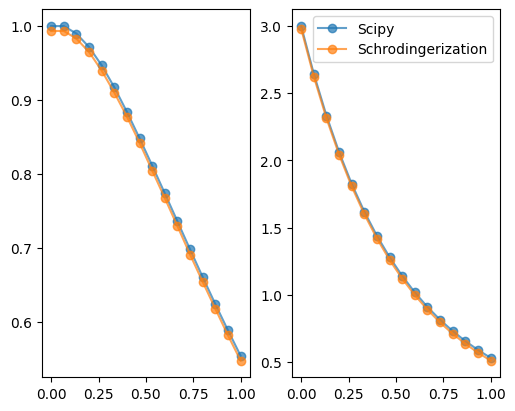

In [528]:
F = lambda t, u: A @ u

t_vals = np.linspace(0, T, N_t)
sol = solve_ivp(F, [0, T], u_0, t_eval=t_vals)

fig, axs = plt.subplots(1, dimension, constrained_layout=True, facecolor="white", figsize=(5,4))

aspect = 0.4

for i in range(dimension):

    axs[i].plot(t_vals, sol.y[i], '-o', label="Scipy", alpha=0.7)
    axs[i].plot(t_vals, u_recover[:,i].real, '-o', label="Schrodingerization", alpha=0.7)

plt.legend()
plt.show()

Solve a linear system via gradient flow

In [529]:
def solve_gradient_flow(A, b, x_0, N, L, R, T, N_t):
    # The gradient of the optimization problem is Ax-b, so the gradient flow ODE is x'(t) = - Ax + b.
    A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
    print(A_tilde.toarray())
    print("Eigvals: ", eigvals(A_tilde.toarray()))
    u_recover = schrodingerization(A_tilde, vstack([x_0, 1]), N, L, R, T, N_t)
    return u_recover[:,:-1]

In [530]:
# Ax=b, where A is symmetric positive semidefinite
dimension = 2
A = random(dimension, dimension, density=1) + eye(dimension, dimension)
A = (A + A.T) / 2

b = random(dimension, 1, density=1)

print("Eigvals of A:", eigvalsh(A.toarray()))
assert np.alltrue(eigvalsh(A.toarray()) >= 0)

x_0 = random(dimension, 1, density=1)


A = csc_matrix(np.array([[1, 1], [0, 1]]))
b = csc_matrix(np.array([[1, 0]]).T)
x_0 = csc_matrix(np.array([[0.5, 0.5]]).T)

print(A.toarray())
print(b.toarray())
print(x_0.toarray())

x_sol = spsolve(A, b)
print("Ground truth:", x_sol)

Eigvals of A: [0.78971287 2.35991951]
[[1 1]
 [0 1]]
[[1]
 [0]]
[[0.5]
 [0.5]]
Ground truth: [1. 0.]


In [531]:
L, R = -30, 30
N = 1024
T = 6
N_t = 16
u_recover = solve_gradient_flow(A, b, x_0, N, L, R, T, N_t)

[[-1. -1.  1.]
 [ 0. -1.  0.]
 [ 0.  0.  0.]]
Eigvals:  [-1.+0.j -1.+0.j  0.+0.j]
Eigvals of A: [-1.58504324 -0.65555391  0.24059715]


In [532]:
F_gf = lambda t, u: -A.toarray() @ u + b.toarray().reshape(2)

t_vals = np.linspace(0, T, N_t)
sol_gf = solve_ivp(F_gf, [0, T], x_0.toarray().reshape(2), t_eval=t_vals)

In [533]:
A_tilde = vstack([hstack([-A, b]), csc_matrix((1, A.shape[0]+1))])
u_recover = schrodingerization(A_tilde, vstack([x_0, 1]), N, L, R, T, N_t)

print(eigvals(A_tilde.toarray()))
print(eigvalsh((A_tilde + A_tilde.T).toarray() / 2))
F = lambda t, u: A_tilde @ u
t_vals = np.linspace(0, T, N_t)
sol_augmented = solve_ivp(F, [0, T], vstack([x_0, 1]).toarray().reshape(x_0.getnnz()+1), t_eval=t_vals)

Eigvals of A: [-1.58504324 -0.65555391  0.24059715]
[-1.+0.j -1.+0.j  0.+0.j]
[-1.58504324 -0.65555391  0.24059715]


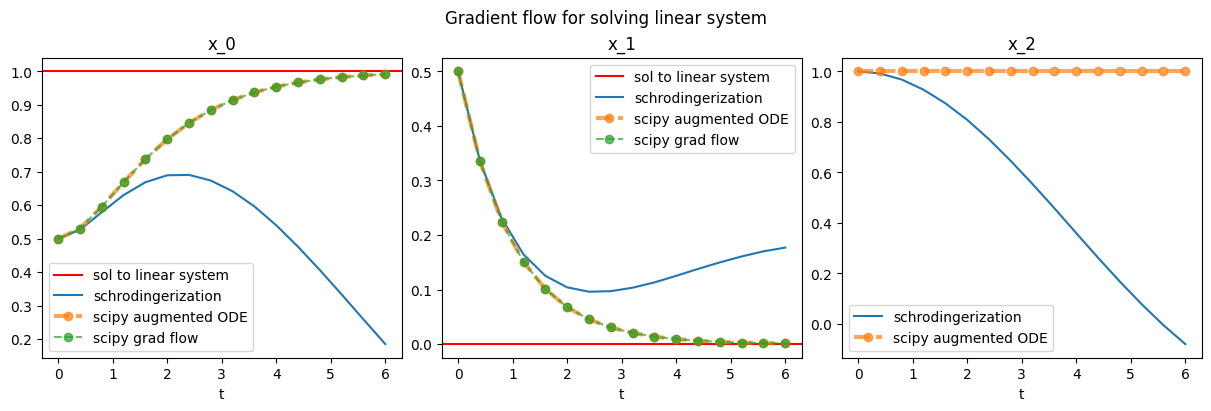

In [534]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, 3, constrained_layout=True, facecolor="white", figsize=(12,4))

aspect = 0.4

for i in range(3):
    if i < 2:
        axs[i].axhline(y=x_sol[i], color='red', label="sol to linear system")

    axs[i].plot(t_vals, u_recover[:,i].real, label="schrodingerization")
    axs[i].plot(t_vals, sol_augmented.y[i], '--o', label="scipy augmented ODE", linewidth=3, alpha=0.7)
    if i < 2:
        axs[i].plot(t_vals, sol_gf.y[i], '--o', label="scipy grad flow", alpha=0.7)
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
plt.suptitle("Gradient flow for solving linear system")
plt.show()

Jacobi method

In [535]:
Lamb = A.diagonal()
M = A - diags(Lamb)
print(M.toarray())

C = vstack([diags((1 / Lamb)) @ hstack([-M, b]), hstack([csc_matrix((1, A.shape[0])), [1]])])
print(eigvals(C.toarray()))

[[0. 1.]
 [0. 0.]]
[0.+0.j 0.+0.j 1.+0.j]


In [536]:
F_jac = lambda t, u: (C - eye(A.shape[0] + 1)).toarray() @ u

t_vals = np.linspace(0, T, N_t)
sol_jac = solve_ivp(F_jac, [0, T], vstack([x_0, 1]).toarray().reshape(3), t_eval=t_vals)

In [537]:
u_recover = schrodingerization((C - eye(A.shape[0] + 1)), vstack([x_0, 1]), N, L, R, T, N_t)

Eigvals of A: [-1.58504324 -0.65555391  0.24059715]


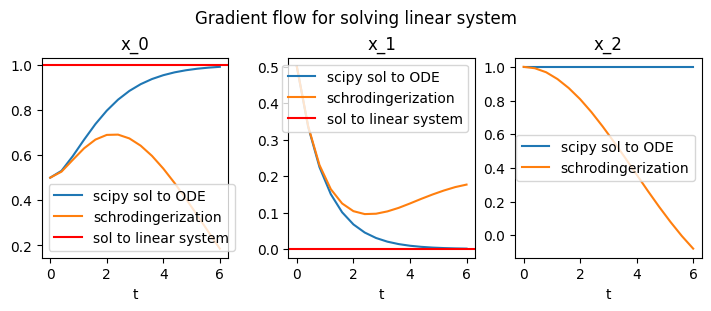

In [538]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(1, 3, constrained_layout=True, facecolor="white", figsize=(7,3))

aspect = 0.4

for i in range(3):
    axs[i].plot(t_vals, sol_jac.y[i], label="scipy sol to ODE")
    axs[i].plot(t_vals, u_recover[:,i].real, label="schrodingerization")
    
    if i < 2:
        axs[i].axhline(y=x_sol[i], color='red', label="sol to linear system")
    axs[i].legend()
    axs[i].set_title(f"x_{i}")
    axs[i].set_xlabel(f"t")
plt.suptitle("Gradient flow for solving linear system")
plt.show()

We consider Laplace's equation.

$$
    \nabla u = 0 \text{ in } \Omega,\\
    u = g \text{ on }\delta\Omega.
$$

Ground truth

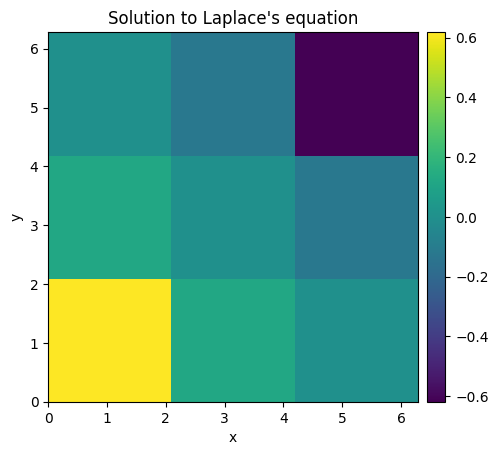

In [45]:
N = 3
L = 0
R = 2 * np.pi
h = (R - L) / (N - 1)

grid = CartesianGrid([[L, R]] * 2, N)
bcs = [{"value": "sin(y)"}, {"value": "sin(x)"}]

res = solve_laplace_equation(grid, bcs)
res.plot()
plt.show()

Solve the linear system

In [46]:
A = get_laplacian(N, 2, L=L, R=R)

# Enforce the boundary conditions
b = np.zeros(N ** 2)
for i in [0, N-1]:
    for j, y in enumerate(np.linspace(L, R, N+2)[1:-1]):
        b[i * N + j] -= np.sin(y) / h ** 2
for j in [0, N-1]:
    for i, x in enumerate(np.linspace(L, R, N+2)[1:-1]):
        b[i * N + j] -= np.sin(x) / h ** 2

b = csc_matrix(b.reshape(N ** 2, 1))

In [47]:
x_sol = spsolve(A, b).reshape((N, N))

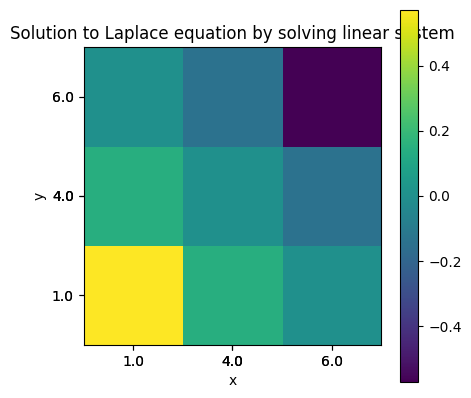

In [48]:
plt.matshow(x_sol.T)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")

plt.tick_params(labelbottom=True, labeltop=False, top=False)
plt.xticks(np.round(np.arange(L, R) / h), np.arange(L, R), )
plt.yticks(np.round(np.arange(L, R) / h), np.arange(L, R))
plt.gca().invert_yaxis()
plt.title("Solution to Laplace equation by solving linear system")
plt.show()

In [86]:
L_p, R_p = -5, 5
N_p = 64
u_recover = solve_gradient_flow(-A, -b, b, N=N_p, L=L_p, R=R_p, T=T, N_t=N_t)

[-0.69186432 -0.54857453 -0.54857453 -0.40528473 -0.40528473 -0.40528473
 -0.26199494 -0.26199494 -0.11870515  0.        ]
Eigvals of A: [-0.69186432 -0.5677913  -0.54857453 -0.40528473 -0.40528473 -0.40528473
 -0.2928267  -0.26199494 -0.11870515  0.05004853]
(640, 640)


In [87]:
x_sol_recover = u_recover[-1].reshape((N,N))

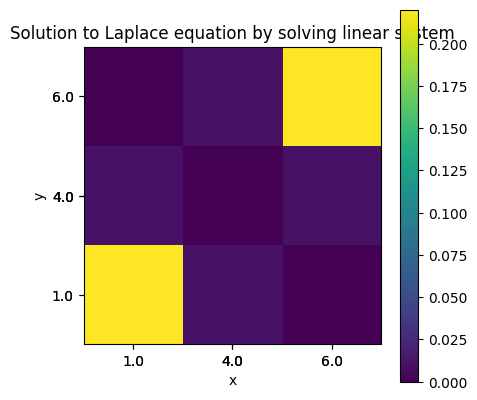

In [88]:
plt.matshow(x_sol_recover.T)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")

plt.tick_params(labelbottom=True, labeltop=False, top=False)
plt.xticks(np.round(np.arange(L, R) / h), np.arange(L, R))
plt.yticks(np.round(np.arange(L, R) / h), np.arange(L, R))
plt.gca().invert_yaxis()
plt.title("Solution to Laplace equation by solving linear system")
plt.show()

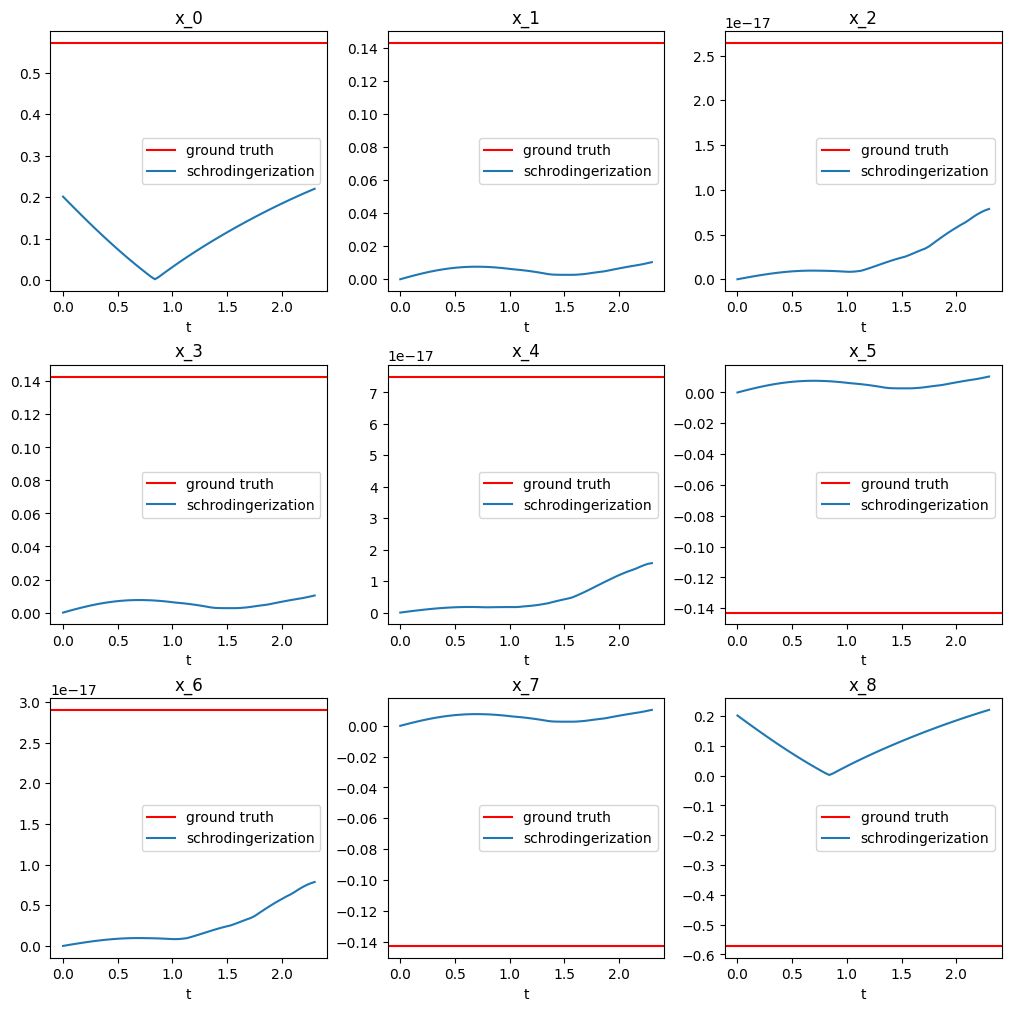

In [89]:
t_vals = np.linspace(0, T, N_t)

fig, axs = plt.subplots(N, N, constrained_layout=True, facecolor="white", figsize=(10,10))

aspect = 0.4
ax = axs.flatten()

for i in range(len(ax)):
    ax[i].axhline(y=x_sol.flatten()[i], color='red', label="ground truth")
    ax[i].plot(t_vals, u_recover[:,i].real, label="schrodingerization")
    ax[i].legend()
    ax[i].set_title(f"x_{i}")
    ax[i].set_xlabel(f"t")
plt.show()